Full CICIDS 2017 Dataset

1. Setup and Dataset Extraction

In [ ]:
# ==============================================================================
# CELL 1: SETUP AND DATASET EXTRACTION
# ==============================================================================
import os
import gc
import zipfile
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm

ZIP_PATH = '/content/MachineLearningCSV.zip'
EXTRACT_PATH = '/content/cicids_data'

if os.path.exists(ZIP_PATH):
    print("🔄 Unzipping MachineLearningCSV.zip...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("✅ Extraction complete.")
else:
    print(f"❌ Error: {ZIP_PATH} not found. Please upload the zip to /content/")

csv_files = glob.glob(os.path.join(EXTRACT_PATH, "MachineLearningCVE", "*.csv"))
print(f"📊 Found {len(csv_files)} CSV files for processing.")

🔄 Unzipping MachineLearningCSV.zip...
✅ Extraction complete.
📊 Found 8 CSV files for processing.


2. Data Cleaning and Merging

In [ ]:
# ==============================================================================
# CELL 2: DATA CLEANING & MERGING (100% DATASET SCALE)
# ==============================================================================
import numpy as np
import pandas as pd
import gc
from tqdm import tqdm

def downcast_df(df):
    """Reduces memory footprint by converting 64-bit to 32-bit types."""
    fcols = df.select_dtypes('float').columns
    icols = df.select_dtypes('integer').columns
    df[fcols] = df[fcols].apply(pd.to_numeric, downcast='float')
    df[icols] = df[icols].apply(pd.to_numeric, downcast='integer')

    if 'MappedLabel' in df.columns:
        df['MappedLabel'] = df['MappedLabel'].astype('category')
    return df

def clean_and_merge(files, sample_rate=1.0):
    df_list = []

    label_map = {
        'BENIGN': 'Benign', 'DDoS': 'DDoS', 'DoS Hulk': 'DoS',
        'DoS GoldenEye': 'DoS', 'DoS slowloris': 'DoS',
        'DoS Slowhttptest': 'DoS', 'PortScan': 'Probe',
        'Bot': 'Probe', 'FTP-Patator': 'R2L', 'SSH-Patator': 'R2L',
        'Infiltration': 'U2R', 'Heartbleed': 'DoS',
        'Web Attack Brute Force': 'Web Attack',
        'Web Attack XSS': 'Web Attack',
        'Web Attack Sql Injection': 'Web Attack'
    }

    for file in tqdm(files, desc="Cleaning & Merging (100% Scale)"):
        temp_df = pd.read_csv(file)
        temp_df.columns = temp_df.columns.str.strip()

        temp_df.replace([np.inf, -np.inf], np.nan, inplace=True)

        for col in ['Flow Bytes/s', 'Flow Packets/s']:
            if col in temp_df.columns:
                temp_df[col] = temp_df[col].fillna(temp_df[col].median())

        temp_df.dropna(inplace=True)
        temp_df.drop_duplicates(inplace=True)

        if sample_rate < 1.0:
            temp_df = temp_df.sample(frac=sample_rate, random_state=42)

        temp_df['MappedLabel'] = temp_df['Label'].str.replace(r'\s+', ' ', regex=True).map(label_map).fillna('Benign')
        temp_df.drop('Label', axis=1, inplace=True)

        df_list.append(downcast_df(temp_df))

        del temp_df
        gc.collect()

    full_df = pd.concat(df_list, axis=0, ignore_index=True)
    full_df = downcast_df(full_df)

    del df_list
    gc.collect()

    return full_df

# --- EXECUTION ON 100% SCALE ---
df_master = clean_and_merge(csv_files, sample_rate=1.0)

print(f"\n✅ 100% Dataset Scale loaded successfully.")
print(f"📊 Final Rows: {len(df_master):,}")
print(f"💾 Memory Usage: {df_master.memory_usage().sum() / 1024**2:.2f} MB")

Cleaning & Merging (100% Scale): 100%|██████████| 8/8 [00:37<00:00,  4.68s/it]



✅ 100% Dataset Scale loaded successfully.
📊 Final Rows: 2,574,264
💾 Memory Usage: 768.42 MB


3. Data Quality and Class Distribution Analysis

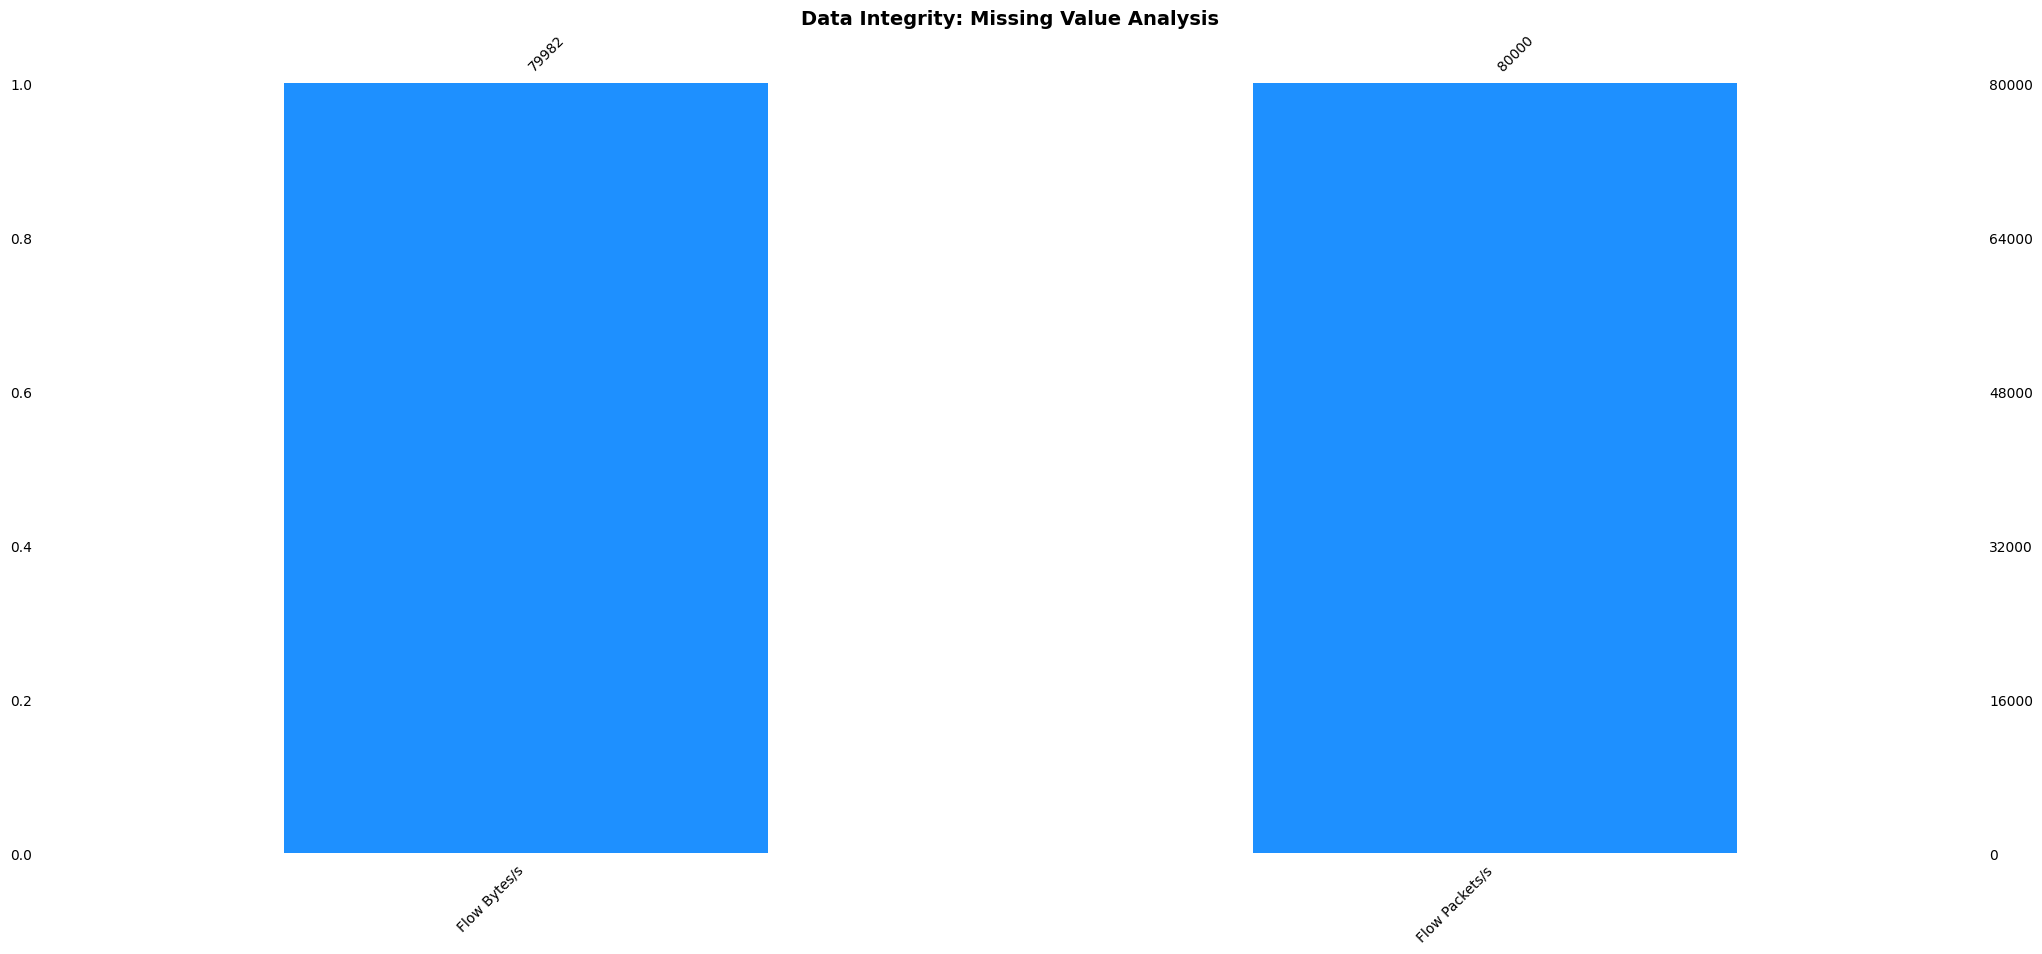

📊 Calculating original class distribution from disk...


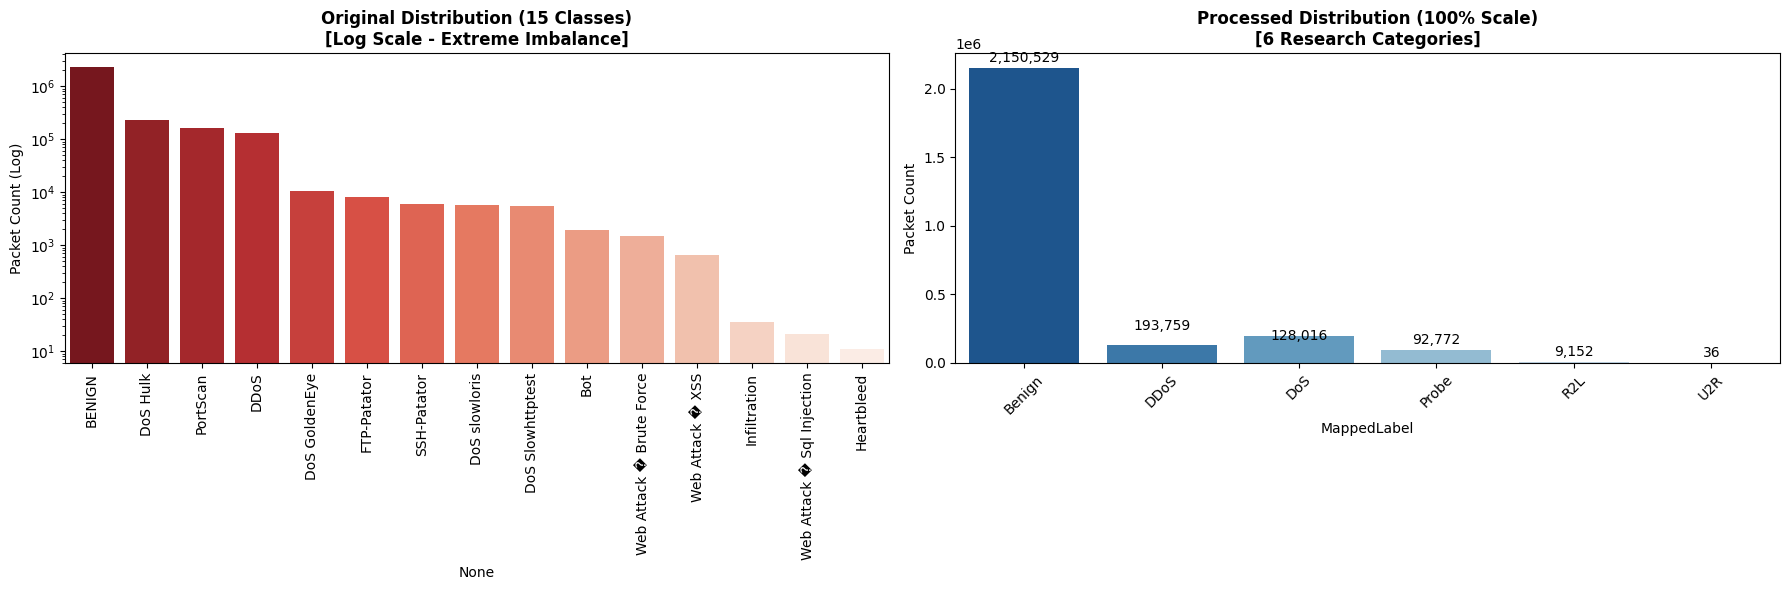

✅ Analysis complete.
🔹 Original Dataset Total: 2,830,743 packets
🔹 Processed 100% Research Sample: 2,574,264 packets


In [ ]:
# ==============================================================================
# CELL 3: DATA QUALITY & CLASS DISTRIBUTION ANALYSIS
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import glob
import missingno as msno
import gc

preview_files = glob.glob('/content/cicids_data/MachineLearningCVE/*.csv')

preview_df = pd.concat([pd.read_csv(f, nrows=10000) for f in preview_files])
preview_df.columns = preview_df.columns.str.strip()

plt.figure(figsize=(10, 4))
msno.bar(preview_df[['Flow Bytes/s', 'Flow Packets/s']], color="dodgerblue", fontsize=10)
plt.title("Data Integrity: Missing Value Analysis", fontsize=14, fontweight='bold')
plt.show()

print("📊 Calculating original class distribution from disk...")
raw_counts = {}
for f in preview_files:
    temp_header = pd.read_csv(f, nrows=0)
    actual_label_col = None
    for col in temp_header.columns:
        if col.strip() == 'Label':
            actual_label_col = col
            break

    if actual_label_col is None:
        continue
    temp_labels = pd.read_csv(f, usecols=[actual_label_col])[actual_label_col].str.strip()
    counts = temp_labels.value_counts()
    for label, count in counts.items():
        raw_counts[label] = raw_counts.get(label, 0) + count
    del temp_labels
    gc.collect()

original_dist = pd.Series(raw_counts).sort_values(ascending=False)
processed_dist = df_master['MappedLabel'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x=original_dist.index, y=original_dist.values, ax=ax[0], palette="Reds_r", hue=original_dist.index, legend=False)
ax[0].set_yscale('log')
ax[0].set_title("Original Distribution (15 Classes)\n[Log Scale - Extreme Imbalance]", fontweight='bold')
ax[0].tick_params(axis='x', rotation=90)
ax[0].set_ylabel("Packet Count (Log)")

sns.barplot(x=processed_dist.index, y=processed_dist.values, ax=ax[1], palette="Blues_r", hue=processed_dist.index, legend=False)
ax[1].set_title("Processed Distribution (100% Scale)\n[6 Research Categories]", fontweight='bold')
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_ylabel("Packet Count")

for i, v in enumerate(processed_dist.values):
    ax[1].text(i, v + (max(processed_dist.values)*0.02), f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"✅ Analysis complete.")
print(f"🔹 Original Dataset Total: {original_dist.sum():,} packets")
print(f"🔹 Processed 100% Research Sample: {processed_dist.sum():,} packets")

4. Deep Feature Engineering & 9x9 Image Generation

In [ ]:
# ==============================================================================
# CELL 4: DEEP FEATURE ENGINEERING & 9x9 IMAGE GENERATION (100% SCALE)
# ==============================================================================
import numpy as np
import pandas as pd
import gc
from tqdm import tqdm
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler, LabelEncoder
from scipy.cluster.hierarchy import linkage, leaves_list

def elite_preprocess(files, sample_rate=1.0):
    df_list = []

    attack_map = {
        'BENIGN': 'BENIGN', 'DDoS': 'DDoS', 'DoS Hulk': 'DoS',
        'DoS GoldenEye': 'DoS', 'DoS slowloris': 'DoS',
        'DoS Slowhttptest': 'DoS', 'PortScan': 'Port Scan',
        'Bot': 'Bot', 'FTP-Patator': 'Brute Force', 'SSH-Patator': 'Brute Force',
        'Infiltration': 'Infiltration', 'Web Attack  Brute Force': 'Web Attack',
        'Web Attack  XSS': 'Web Attack', 'Web Attack  Sql Injection': 'Web Attack',
        'Heartbleed': 'Heartbleed'
    }
    for file in tqdm(files, desc="Processing CSVs (100% Scale)"):
        df = pd.read_csv(file)
        df.columns = df.columns.str.strip()
        df.drop_duplicates(inplace=True)
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        if 'Flow Bytes/s' in df.columns:
            df['Flow Bytes/s'] = df['Flow Bytes/s'].fillna(df['Flow Bytes/s'].median())
        if 'Flow Packets/s' in df.columns:
            df['Flow Packets/s'] = df['Flow Packets/s'].fillna(df['Flow Packets/s'].median())
        if sample_rate < 1.0:
            df = df.sample(frac=sample_rate, random_state=42)

        df['Attack Type'] = df['Label'].str.replace(r'\s+', ' ', regex=True).map(attack_map).fillna('BENIGN')
        df.drop('Label', axis=1, inplace=True)
        fcols = df.select_dtypes('float').columns
        df[fcols] = df[fcols].astype('float32')
        icols = df.select_dtypes('integer').columns
        df[icols] = df[icols].astype('int32')

        df_list.append(df)
        gc.collect()

    return pd.concat(df_list, axis=0, ignore_index=True)

df_master = elite_preprocess(csv_files, sample_rate=1.0)
print(f"✅ Data Loaded. Total Samples: {len(df_master):,}")

features = df_master.drop('Attack Type', axis=1)
features = features.loc[:, features.std() > 0]

print("🔄 Calculating Hierarchical Correlation (Grouping features)...")
corr = features.corr().fillna(0).values
Z = linkage(corr, 'ward')
new_order = leaves_list(Z)
ordered_features = features.iloc[:, new_order]

print("⚖️ Applying Quantile Mapping (Normalizing distribution)...")
qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000,
                         subsample=100000, random_state=42)
mm = MinMaxScaler()
scaled_data = mm.fit_transform(qt.fit_transform(ordered_features)).astype('float32')

pad_size = 81 - scaled_data.shape[1]
padding = np.zeros((scaled_data.shape[0], pad_size), dtype='float32')
images_9x9 = np.hstack([scaled_data, padding]).reshape(-1, 9, 9)

le = LabelEncoder()
y_encoded = le.fit_transform(df_master['Attack Type'])

gc.collect()

print(f"\n✅ 100% PREPROCESSING COMPLETE")
print(f"🔹 Tabular Input Shape: {scaled_data.shape[1]}")
print(f"🔹 Image Input Shape: {images_9x9.shape[1]}x{images_9x9.shape[2]}")
print(f"🔹 Total Classes Found: {len(le.classes_)} ({list(le.classes_)})")

Processing CSVs (100% Scale): 100%|██████████| 8/8 [00:33<00:00,  4.14s/it]


✅ Data Loaded. Total Samples: 2,574,264
🔄 Calculating Hierarchical Correlation (Grouping features)...
⚖️ Applying Quantile Mapping (Normalizing distribution)...

✅ 100% PREPROCESSING COMPLETE
🔹 Tabular Input Shape: 70
🔹 Image Input Shape: 9x9
🔹 Total Classes Found: 8 (['BENIGN', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'Heartbleed', 'Infiltration', 'Port Scan'])


5. Correlation Structural Analysis

📊 Generating correlation heatmaps...


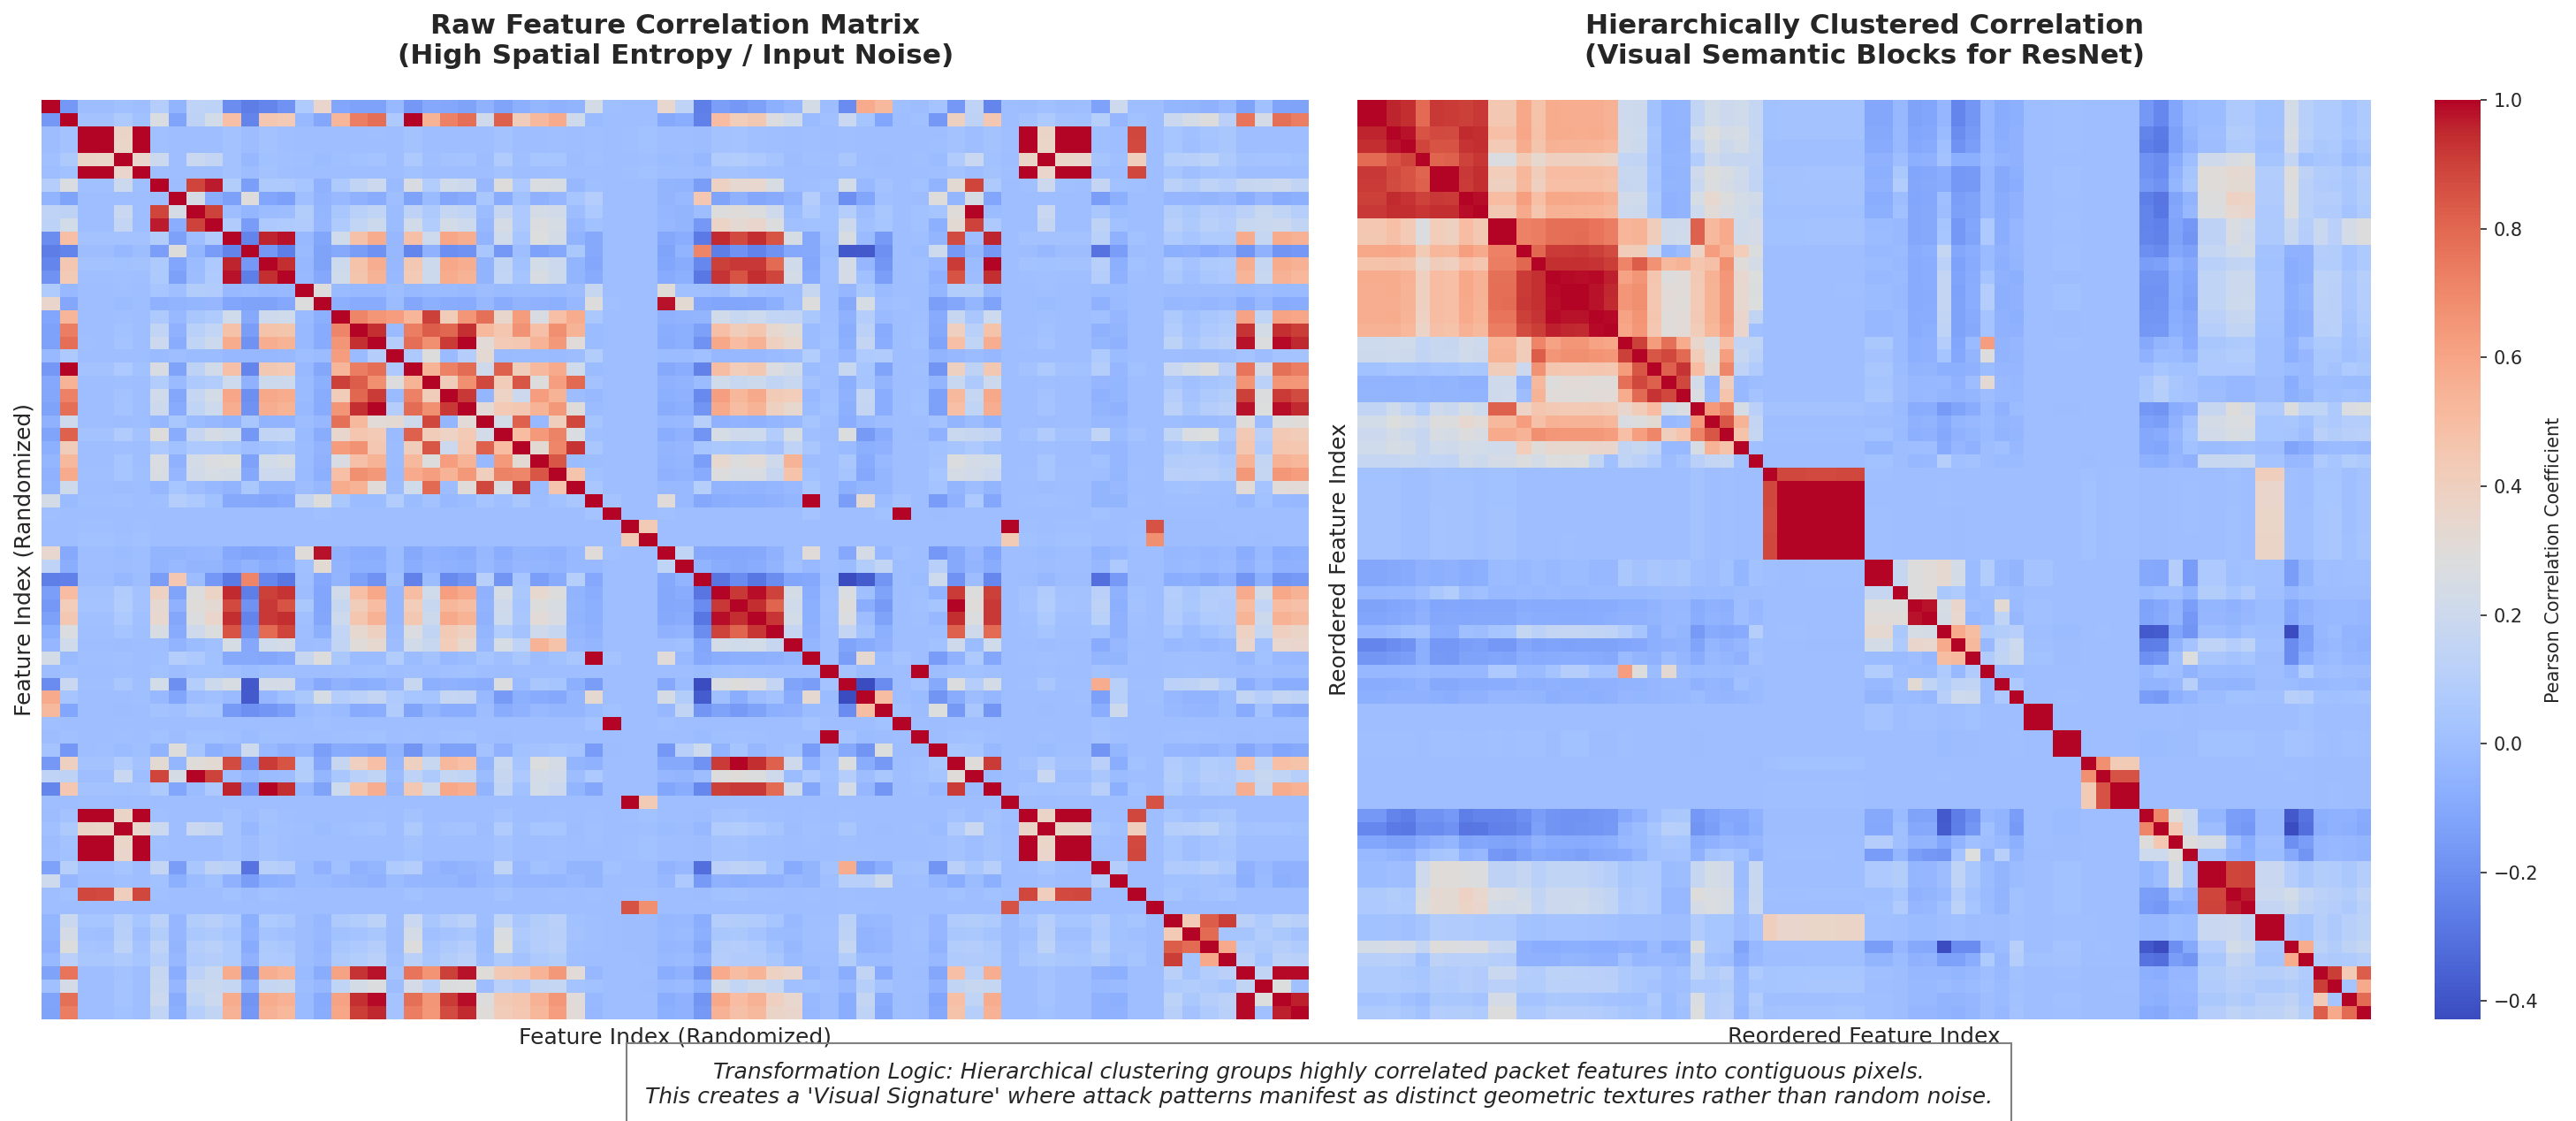

✅ Visualization generated. Reordering clustered 70 features.


In [ ]:
# ==============================================================================
# CELL 5: CORRELATION STRUCTURAL ANALYSIS
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 150
sns.set_style("white")

print("📊 Generating correlation heatmaps...")

original_corr = features.corr().fillna(0)
reordered_corr = ordered_features.corr().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(20, 9))

sns.heatmap(original_corr, cmap='coolwarm', ax=ax[0],
            cbar=False, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True)
ax[0].set_title("Raw Feature Correlation Matrix\n(High Spatial Entropy / Input Noise)",
                fontsize=15, fontweight='bold', pad=20)
ax[0].set_xlabel("Feature Index (Randomized)", fontsize=12)
ax[0].set_ylabel("Feature Index (Randomized)", fontsize=12)

sns.heatmap(reordered_corr, cmap='coolwarm', ax=ax[1],
            cbar=True, xticklabels=False, yticklabels=False,
            linewidths=0.0, rasterized=True,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax[1].set_title("Hierarchically Clustered Correlation\n(Visual Semantic Blocks for ResNet)",
                fontsize=15, fontweight='bold', pad=20)
ax[1].set_xlabel("Reordered Feature Index", fontsize=12)
ax[1].set_ylabel("Reordered Feature Index", fontsize=12)

fig.text(0.5, 0.02,
         "Transformation Logic: Hierarchical clustering groups highly correlated packet features into contiguous pixels.\n"
         "This creates a 'Visual Signature' where attack patterns manifest as distinct geometric textures rather than random noise.",
         ha='center', fontsize=12, style='italic', bbox=dict(facecolor='none', edgecolor='gray', pad=10))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

print(f"✅ Visualization generated. Reordering clustered {len(features.columns)} features.")

6. Visualizing Network Flow "Fingerprints" (9x9 Signatures)

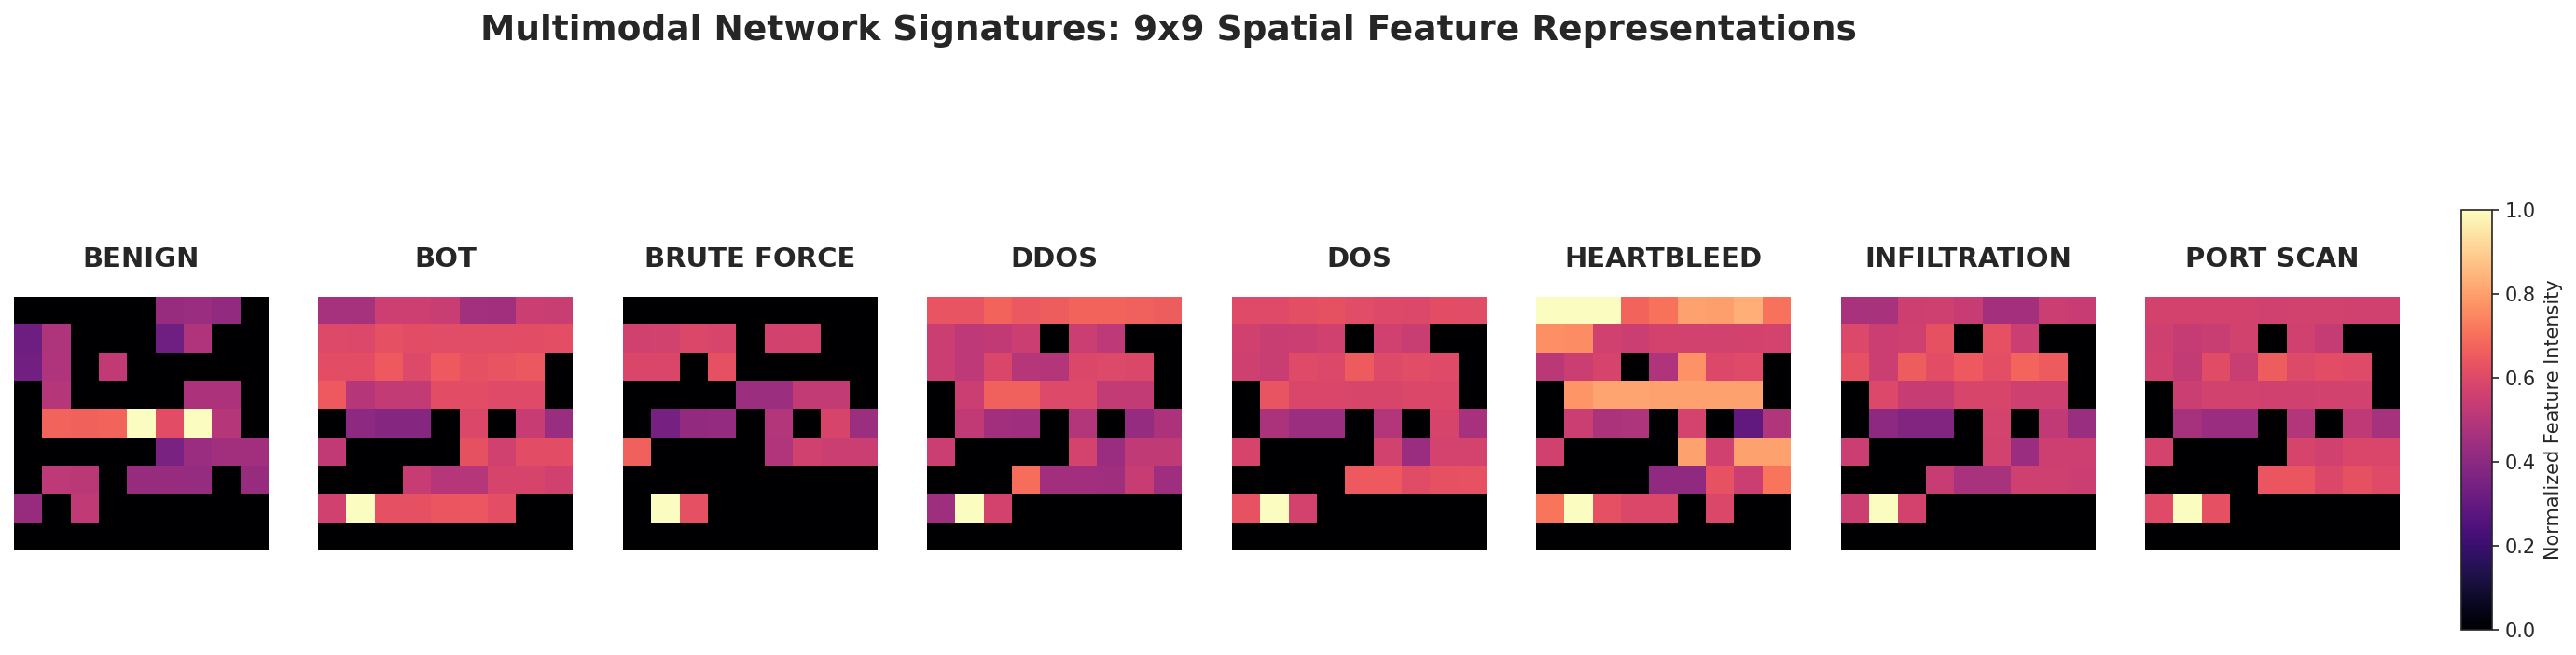

In [ ]:
# ==============================================================================
# CELL 6: VISUALIZING NETWORK FLOW SIGNATURES
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

unique_classes = np.unique(le.inverse_transform(y_encoded))
n_classes = len(unique_classes)

fig, axes = plt.subplots(1, n_classes, figsize=(22, 5))

for i, attack in enumerate(unique_classes):
    target_idx = np.where(le.classes_ == attack)[0][0]
    idx = np.where(y_encoded == target_idx)[0][0]

    img = images_9x9[idx]

    im = axes[i].imshow(img, cmap='magma', interpolation='nearest', vmin=0, vmax=1)
    axes[i].set_title(f"{attack.upper()}", fontsize=14, fontweight='bold', pad=15)
    axes[i].set_xticks(np.arange(-.5, 9, 1), minor=True)
    axes[i].set_yticks(np.arange(-.5, 9, 1), minor=True)
    axes[i].grid(which='minor', color='w', linestyle='-', linewidth=0.5, alpha=0.2)
    axes[i].axis('off')

cbar_ax = fig.add_axes([0.92, 0.2, 0.01, 0.6])
fig.colorbar(im, cax=cbar_ax, label='Normalized Feature Intensity')

plt.suptitle("Multimodal Network Signatures: 9x9 Spatial Feature Representations",
             fontsize=18, y=1.08, fontweight='bold')
plt.show()

7. Statistical Evidence of Visual Separability

📊 STATISTICAL EDA: MULTIMODAL FEATURE DENSITY
------------------------------------------------------------
Attack Category | Mean Intensity  | Std Deviation  
------------------------------------------------------------
BENIGN          | 0.2775          | 0.2787
Bot             | 0.2790          | 0.2771
Brute Force     | 0.3171          | 0.2863
DDoS            | 0.3187          | 0.2897
DoS             | 0.3743          | 0.2968
Heartbleed      | 0.3997          | 0.3506
Infiltration    | 0.4227          | 0.3069
Port Scan       | 0.2031          | 0.2539


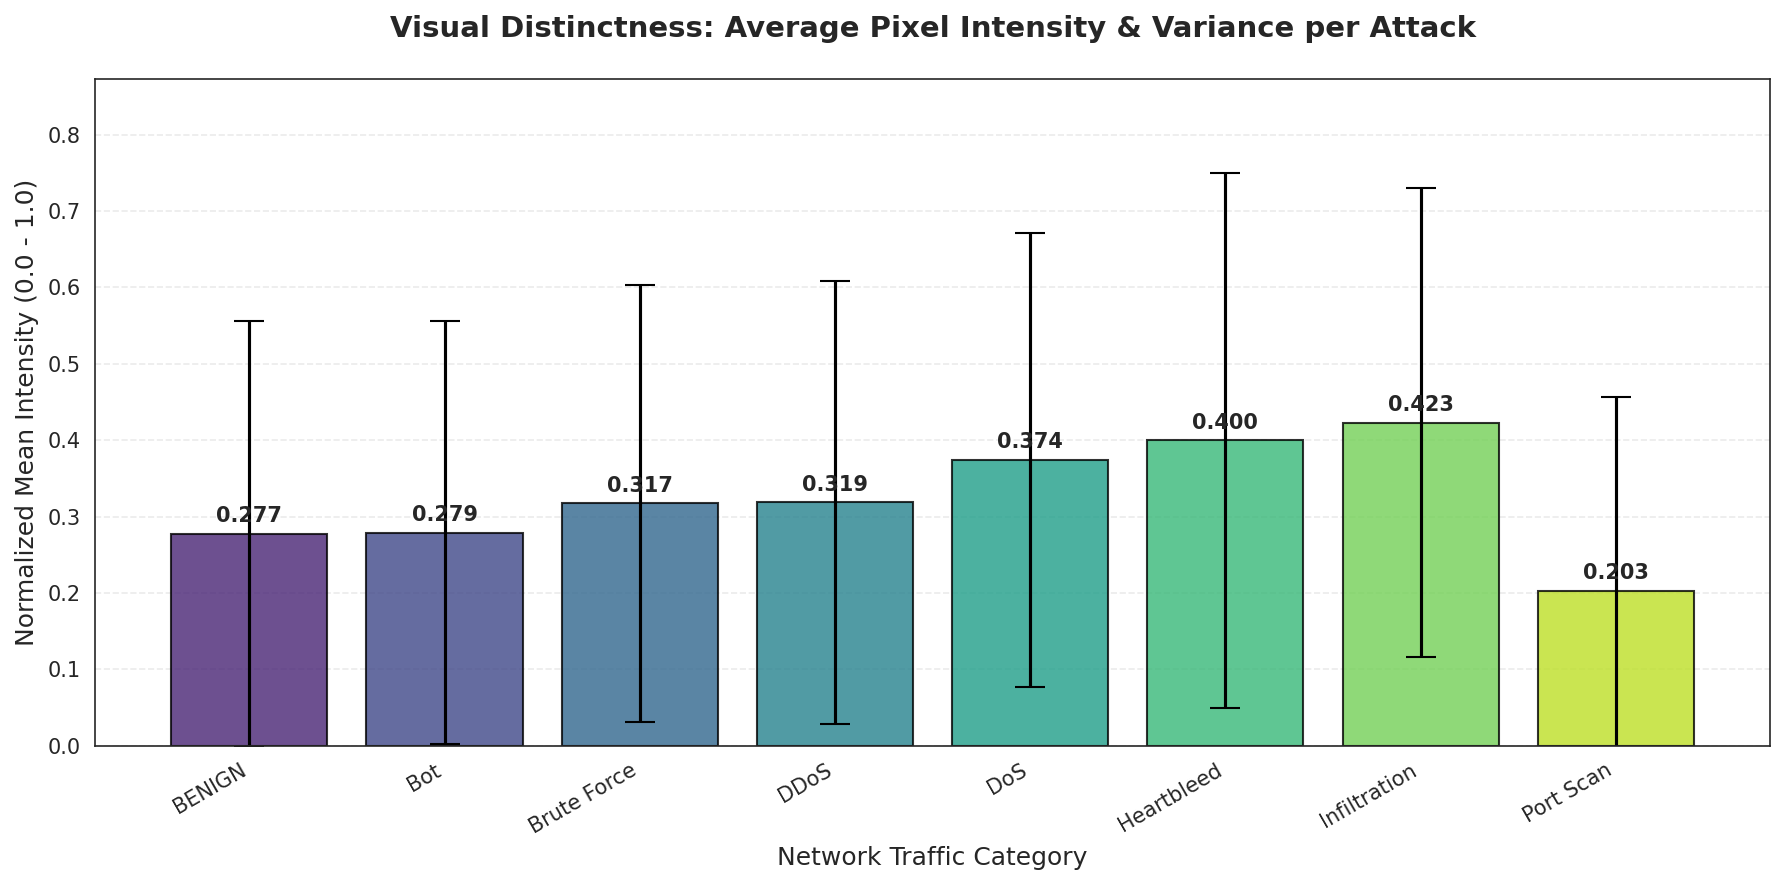

In [ ]:
# ==============================================================================
# CELL 7: CLASS INTENSITY & STATISTICAL ANALYSIS
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt

class_intensity = []
class_std = []

print("📊 STATISTICAL EDA: MULTIMODAL FEATURE DENSITY")
print("-" * 60)
print(f"{'Attack Category':<15} | {'Mean Intensity':<15} | {'Std Deviation':<15}")
print("-" * 60)

for i, attack in enumerate(le.classes_):
    mask = y_encoded == i
    mean_val = np.mean(images_9x9[mask])
    std_val = np.std(images_9x9[mask])

    class_intensity.append(mean_val)
    class_std.append(std_val)

    print(f"{attack:<15} | {mean_val:.4f}          | {std_val:.4f}")

plt.figure(figsize=(12, 6))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(le.classes_)))
bars = plt.bar(le.classes_, class_intensity, yerr=class_std,
               color=colors, capsize=7, edgecolor='black', alpha=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01,
             f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.title("Visual Distinctness: Average Pixel Intensity & Variance per Attack",
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Normalized Mean Intensity (0.0 - 1.0)", fontsize=12)
plt.xlabel("Network Traffic Category", fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.ylim(0, max(class_intensity) + max(class_std) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

8. RAM-Safe Multimodal Dataset Definition

In [ ]:
# ==============================================================================
# CELL 8: RAM-SAFE MULTIMODAL DATASET
# ==============================================================================
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import numpy as np

class MultimodalDataset(Dataset):
    def __init__(self, tabular, images_9x9, labels):
        self.tabular = torch.FloatTensor(tabular)
        self.labels = torch.LongTensor(labels)

        if images_9x9.max() <= 1.0:
            self.images = torch.ByteTensor((images_9x9 * 255).astype(np.uint8))
        else:
            self.images = torch.ByteTensor(images_9x9.astype(np.uint8))

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tab = self.tabular[idx]
        img = self.images[idx].unsqueeze(0).repeat(3, 1, 1).float() / 255.0
        img = self.transform(img)
        return tab, img, self.labels[idx]

print("✅ MultimodalDataset with Lazy Loading ready for 100% Scale.")

✅ MultimodalDataset with Lazy Loading ready for 100% Scale.


9. Multimodal ResNet Architecture with Contextual Attention Fusion

In [ ]:
# ==============================================================================
# CELL 9: MULTIMODAL RESNET ARCHITECTURE
# ==============================================================================
import torch.nn as nn
from torchvision import models

class EliteMultimodalResNet(nn.Module):
    def __init__(self, num_classes, num_tab_features):
        super().__init__()

        # 1. VISION BRANCH: Pre-trained ResNet-18
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
        self.resnet.fc = nn.Linear(512, 128)

        # 2. TABULAR BRANCH: MLP
        self.mlp = nn.Sequential(
            nn.Linear(num_tab_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128)
        )

        # 3. ATTENTION FUSION MECHANISM
        self.attention = nn.Sequential(
            nn.Linear(128 + 128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )

        # 4. FINAL CLASSIFIER
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, tab, img):
        z_v = self.resnet(img)
        z_t = self.mlp(tab)

        combined = torch.cat((z_v, z_t), dim=1)
        attn_weights = self.attention(combined)

        fused = attn_weights[:, 0].unsqueeze(1) * z_v + \
                attn_weights[:, 1].unsqueeze(1) * z_t

        return self.classifier(fused)

print("✅ EliteMultimodalResNet Architecture defined.")

✅ EliteMultimodalResNet Architecture defined.


10. Data Partitioning & Smoothed Class Balancing (100% Scale)

In [ ]:
# ==============================================================================
# CELL 10: DATA PARTITIONING & SAMPLER SETUP (100% SCALE)
# ==============================================================================
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, WeightedRandomSampler

# 1. Stratified Train-Test Split on 100% Data
X_t_tr, X_t_te, X_i_tr, X_i_te, y_tr, y_te = train_test_split(
    scaled_data, images_9x9, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 2. Square Root Class Weight Smoothing
counts = np.bincount(y_tr)
class_weights_smooth = np.sqrt(len(y_tr) / (counts + 1e-6))
sample_weights = class_weights_smooth[y_tr]
sampler = WeightedRandomSampler(sample_weights, len(y_tr))

# 3. High-Efficiency DataLoaders
train_loader = DataLoader(
    MultimodalDataset(X_t_tr, X_i_tr, y_tr),
    batch_size=256, # Increased batch size for full dataset efficiency
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    MultimodalDataset(X_t_te, X_i_te, y_te),
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ Data split complete. Training on {len(y_tr):,} samples at 100% scale.")

✅ Data split complete. Training on 2,059,411 samples at 100% scale.


11. Focal Loss & Differential Optimization (4 Epochs)

In [ ]:
# ==============================================================================
# CELL 11: FOCAL LOSS & OPTIMIZER CONFIGURATION (4-EPOCH CONVERGENCE)
# ==============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EliteMultimodalResNet(
    num_classes=len(le.classes_),
    num_tab_features=X_t_tr.shape[1]
).to(device)

alpha_tensor = torch.FloatTensor(class_weights_smooth).to(device)
criterion = FocalLoss(alpha=alpha_tensor, gamma=2.5)

optimizer = optim.AdamW([
    {'params': model.resnet.parameters(), 'lr': 1e-4},
    {'params': model.mlp.parameters(), 'lr': 1e-3},
    {'params': model.attention.parameters(), 'lr': 1e-3},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
], weight_decay=0.01)

# Strictly set to 4 Epochs for rapid convergence and optimal generalization
total_epochs = 4

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[2e-4, 2e-3, 2e-3, 2e-3],
    epochs=total_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.2
)

scaler = torch.amp.GradScaler('cuda')
print(f"✅ Setup complete. Ready for {total_epochs}-epoch training on device: {device}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 228MB/s]


✅ Setup complete. Ready for 4-epoch training on device: cuda


12. High-Performance Training Loop (4 Epochs)

In [ ]:
# ==============================================================================
# CELL 12: 4-EPOCH HIGH-PERFORMANCE TRAINING LOOP
# ==============================================================================
from sklearn.metrics import f1_score, accuracy_score
import copy
from tqdm import tqdm

history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
best_f1 = 0
best_weights = copy.deepcopy(model.state_dict())

print(f"🚀 Training on 100% Scale ({len(y_tr):,} samples) for {total_epochs} Epochs...")

for epoch in range(total_epochs):
    model.train()
    epoch_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}")

    for tab, img, labels in loop:
        tab, img, labels = tab.to(device), img.to(device), labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type='cuda'):
            outputs = model(tab, img)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")

    # Validation Phase
    model.eval()
    y_true_list, y_pred_list = [], []
    with torch.no_grad():
        for tab, img, labels in test_loader:
            tab, img, labels = tab.to(device), img.to(device), labels.to(device)
            outputs = model(tab, img)
            preds = torch.argmax(outputs, dim=1)
            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    current_f1 = f1_score(y_true_list, y_pred_list, average='macro', zero_division=0)
    current_acc = accuracy_score(y_true_list, y_pred_list)
    avg_train_loss = epoch_loss / len(train_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(current_acc)
    history['val_f1'].append(current_f1)

    print(f"\n📊 [Epoch {epoch+1}/{total_epochs}] Train Loss: {avg_train_loss:.4f} | Val Acc: {current_acc:.4f} | Macro F1: {current_f1:.4f}")

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_weights = copy.deepcopy(model.state_dict())
        print("⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed")

model.load_state_dict(best_weights)
print("\n🏁 Training complete. Peak model weights restored.")

🚀 Training on 100% Scale (2,059,411 samples) for 4 Epochs...


Epoch 1/4:   0%|          | 0/8045 [00:00<?, ?it/s]/tmp/ipykernel_667/1708841504.py:33: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Epoch 1/4: 100%|██████████| 8045/8045 [45:08<00:00,  2.97it/s, loss=0.0020]



📊 [Epoch 1/4] Train Loss: 0.2067 | Val Acc: 0.9933 | Macro F1: 0.7400
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


Epoch 2/4: 100%|██████████| 8045/8045 [49:24<00:00,  2.71it/s, loss=0.0029]



📊 [Epoch 2/4] Train Loss: 0.0337 | Val Acc: 0.9956 | Macro F1: 0.8263
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


Epoch 3/4: 100%|██████████| 8045/8045 [47:48<00:00,  2.80it/s, loss=0.0042]



📊 [Epoch 3/4] Train Loss: 0.0145 | Val Acc: 0.9964 | Macro F1: 0.8665
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed


Epoch 4/4: 100%|██████████| 8045/8045 [47:55<00:00,  2.80it/s, loss=0.0071]



📊 [Epoch 4/4] Train Loss: 0.0078 | Val Acc: 0.9968 | Macro F1: 0.8916
⭐ PEAK PERFORMANCE DETECTED - Model Checkpointed

🏁 Training complete. Peak model weights restored.


13. Evaluation & Comprehensive Metrics Suite

🔍 Running Final Evaluation:   0%|          | 0/2012 [00:00<?, ?it/s]


🏆 GLOBAL PERFORMANCE SUMMARY (4-EPOCH 100% SCALE)
OVERALL ACCURACY:       99.6840%
MACRO PRECISION:        0.8504
MACRO RECALL:           0.9627
MACRO F1-SCORE:         0.8916
INFERENCE LATENCY:      0.7946 ms/packet
SYSTEM THROUGHPUT:      1,258.56 Packets/sec


,precision,recall,f1-score
BENIGN,1.0000,0.9963,0.9981
Bot,0.5079,0.9923,0.6719
Brute Force,0.9127,1.0000,0.9544
DDoS,0.9983,0.9998,0.9991
DoS,0.9803,0.9998,0.9900
Heartbleed,1.0000,1.0000,1.0000
Infiltration,0.4167,0.7143,0.5263
Port Scan,0.9873,0.9993,0.9933


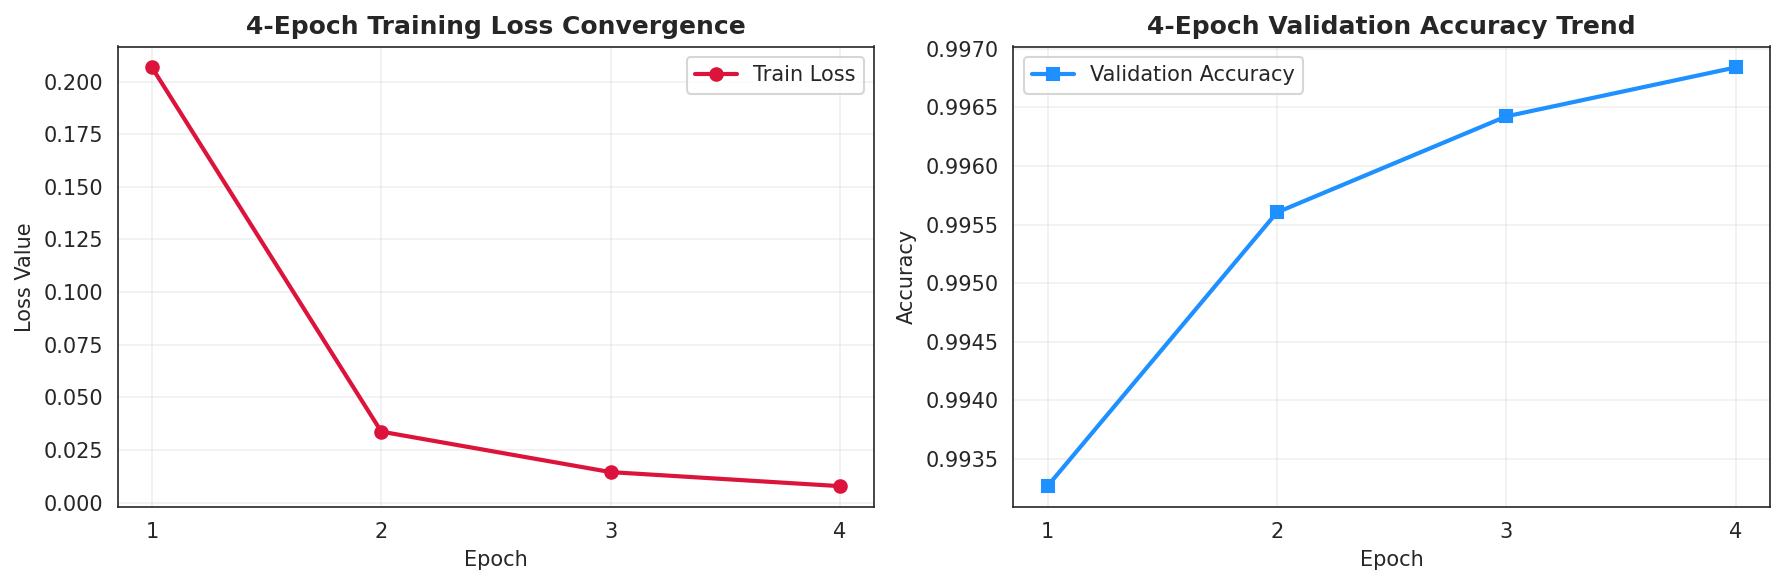

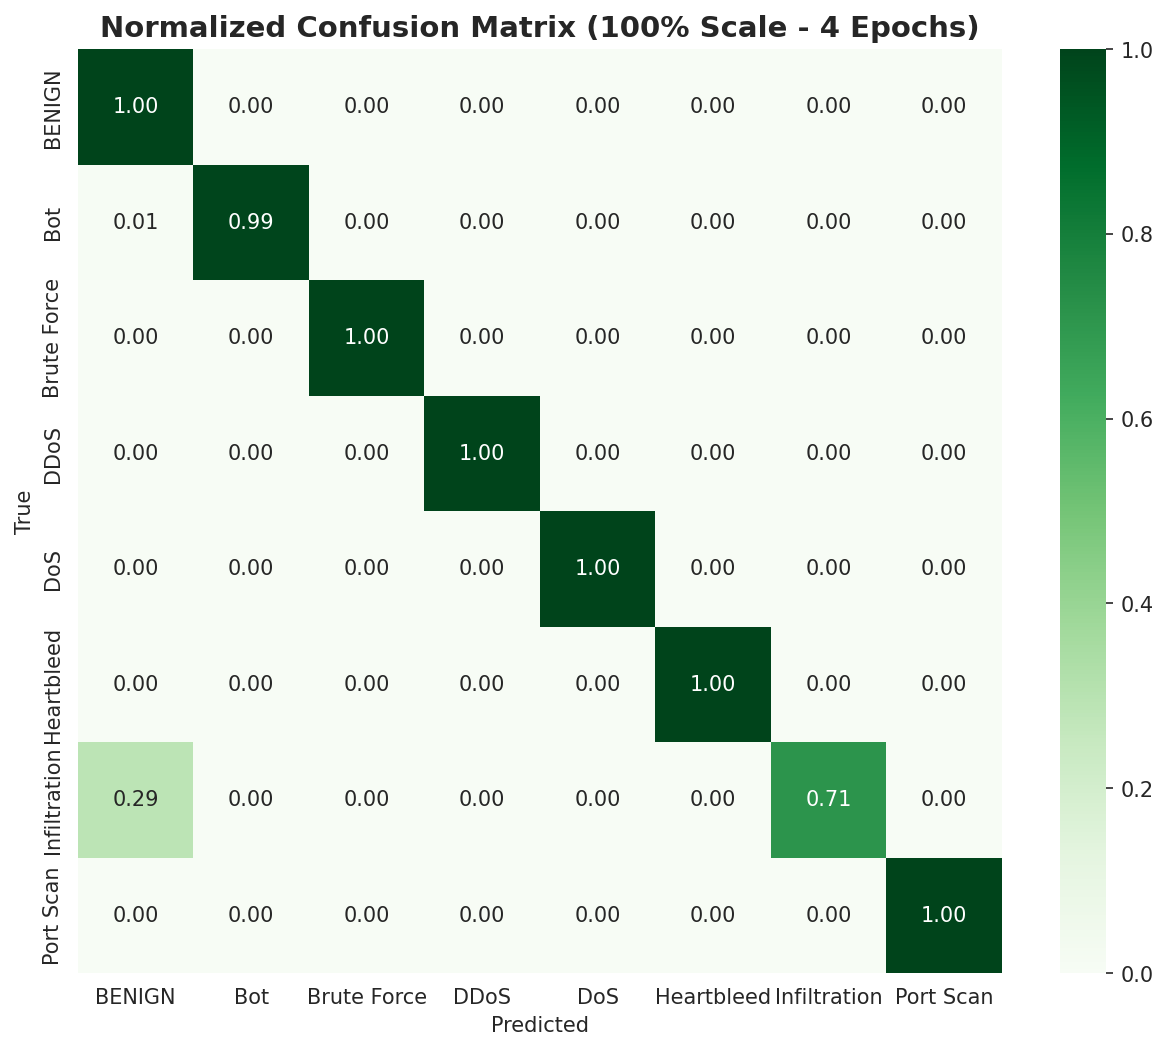

In [ ]:
# ==============================================================================
# CELL 13: EVALUATION & METRICS SUITE (WITH LATENCY & THROUGHPUT BENCHMARKING)
# ==============================================================================
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.metrics import (
    classification_report, precision_recall_fscore_support,
    confusion_matrix, roc_curve, auc, accuracy_score,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize

model.eval()
y_true, y_pred, y_score = [], [], []
total_inference_time_sec = 0.0

with torch.no_grad():
    for tab, img, labels in tqdm(test_loader, desc="🔍 Running Final Evaluation"):
        tab, img = tab.to(device), img.to(device)

        # High-precision CUDA/CPU timing for inference benchmark
        if device.type == 'cuda':
            torch.cuda.synchronize()
        start_time = time.perf_counter()

        outputs = model(tab, img)

        if device.type == 'cuda':
            torch.cuda.synchronize()
        end_time = time.perf_counter()

        total_inference_time_sec += (end_time - start_time)

        probs = torch.softmax(outputs, dim=1)
        y_true.extend(labels.numpy())
        y_pred.extend(torch.argmax(probs, dim=1).cpu().numpy())
        y_score.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

present_labels = np.unique(y_true)
target_names = [le.classes_[i] for i in present_labels]

# Standard Performance Metrics
acc = accuracy_score(y_true, y_pred)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

# Speed & Throughput Benchmarking Computations
total_packets = len(y_true)
latency_ms_per_packet = (total_inference_time_sec / total_packets) * 1000.0
throughput_packets_per_sec = total_packets / total_inference_time_sec

print("\n" + "="*60)
print(f"🏆 GLOBAL PERFORMANCE SUMMARY (4-EPOCH 100% SCALE)")
print("="*60)
print(f"OVERALL ACCURACY:       {acc:.4%}")
print(f"MACRO PRECISION:        {p_macro:.4f}")
print(f"MACRO RECALL:           {r_macro:.4f}")
print(f"MACRO F1-SCORE:         {f1_macro:.4f}")
print(f"INFERENCE LATENCY:      {latency_ms_per_packet:.4f} ms/packet")
print(f"SYSTEM THROUGHPUT:      {throughput_packets_per_sec:,.2f} Packets/sec")
print("="*60)

report_dict = classification_report(
    y_true, y_pred, labels=present_labels, target_names=target_names, digits=4, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.iloc[:-3, :3].style.background_gradient(cmap='Blues').format("{:.4f}"))

# Loss & Accuracy Convergence Curves (Configured for 4 Epochs)
epochs_range = range(1, total_epochs + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], marker='o', color='crimson', linewidth=2, label='Train Loss')
plt.title("4-Epoch Training Loss Convergence", fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.xticks(list(epochs_range))
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['val_acc'], marker='s', color='dodgerblue', linewidth=2, label='Validation Accuracy')
plt.title("4-Epoch Validation Accuracy Trend", fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs_range))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Normalized Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=present_labels)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=target_names, yticklabels=target_names, square=True)
plt.title("Normalized Confusion Matrix (100% Scale - 4 Epochs)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

14. Multimodal XAI & Grad-CAM Explanation Suite


🔍 GENERATING XAI REPORT FOR: BENIGN


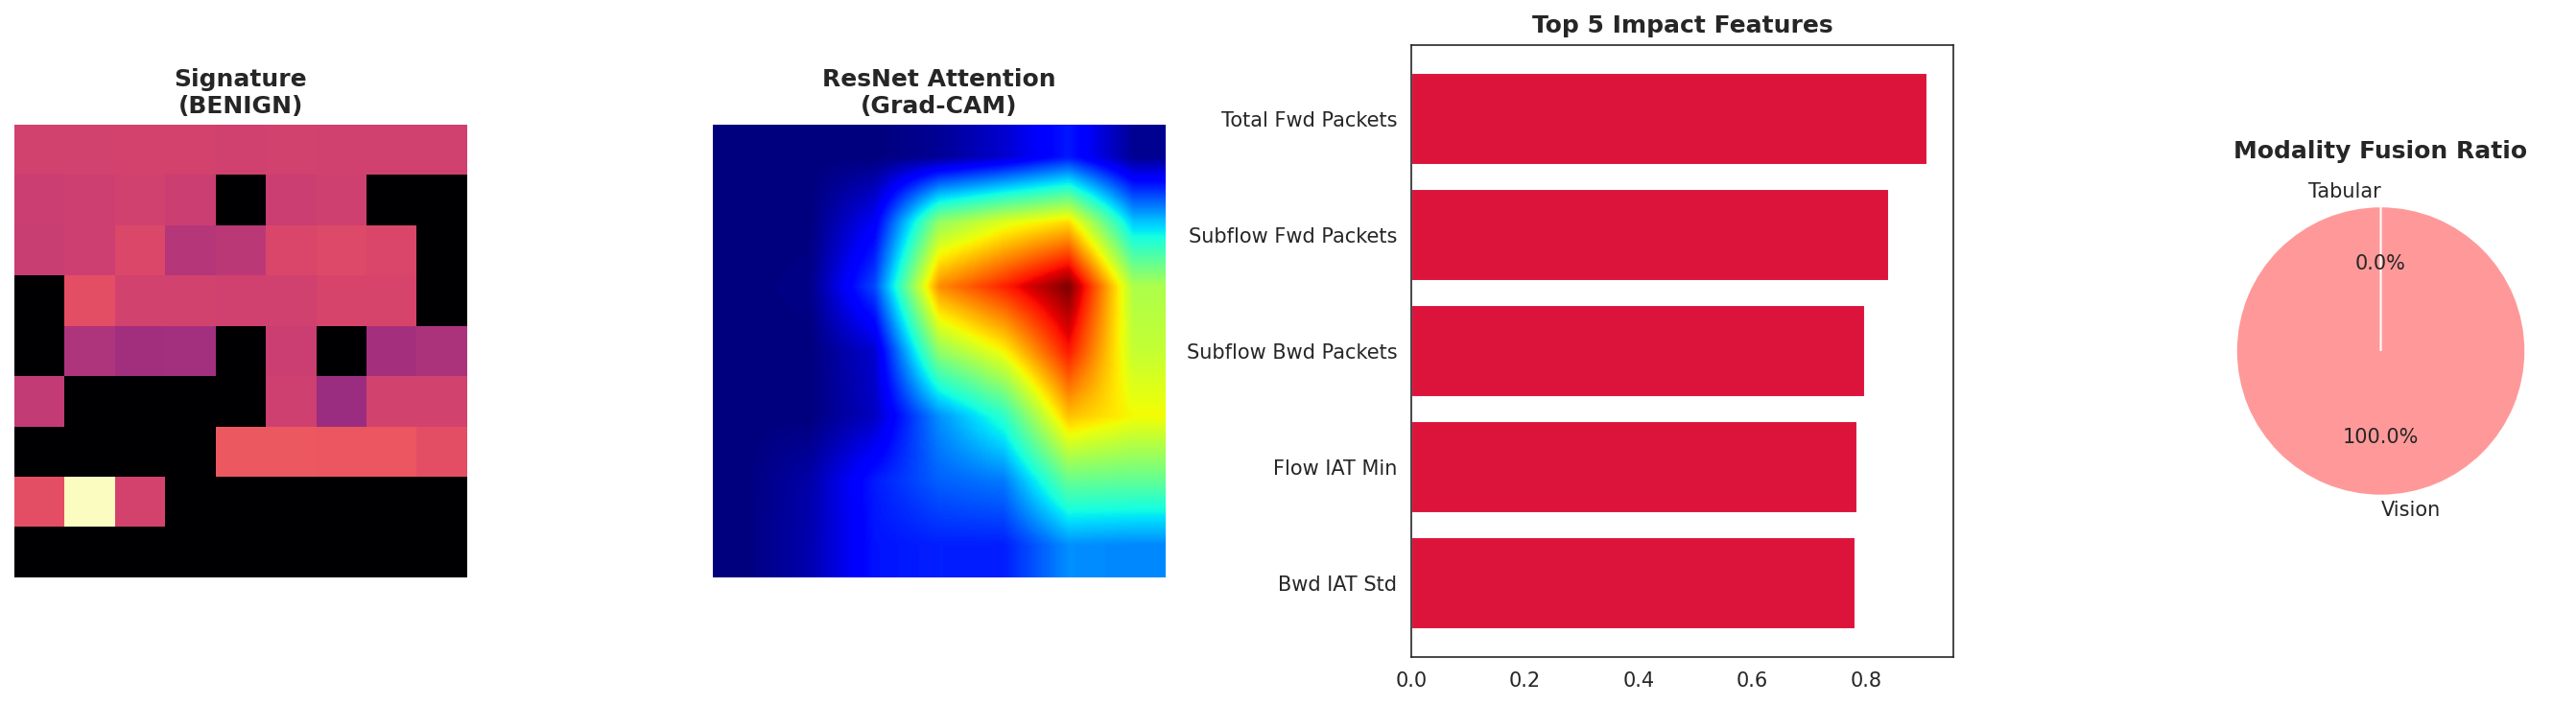

In [ ]:
# ==============================================================================
# CELL 14: MULTIMODAL XAI & SOC ANALYST INTELLIGENCE SUITE
# ==============================================================================
try:
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "grad-cam", "-q"])
    import cv2
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class MultimodalXAIWrapper(nn.Module):
    def __init__(self, original_model, tab_data):
        super().__init__()
        self.model = original_model
        self.tab_data = tab_data

    def forward(self, img):
        return self.model(self.tab_data, img)

def generate_soc_report(sample_idx, target_class_name, model, le, X_t, X_i, features, new_order):
    model.eval()

    tab_sample = torch.FloatTensor(X_t[sample_idx]).unsqueeze(0).to(device)
    img_raw = X_i[sample_idx]

    img_tensor = torch.FloatTensor(img_raw).unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)
    img_tensor = F.interpolate(img_tensor, size=(224, 224), mode='nearest').to(device)

    with torch.no_grad():
        v_feat = model.resnet(img_tensor)
        t_feat = model.mlp(tab_sample)
        combined = torch.cat((v_feat, t_feat), dim=1)
        gate_weights = model.attention(combined).cpu().numpy()[0]

    for param in model.resnet.parameters():
        param.requires_grad = True

    wrapped_model = MultimodalXAIWrapper(model, tab_sample)
    target_layers = [model.resnet.layer4[-1]]
    cam = GradCAM(model=wrapped_model, target_layers=target_layers)

    target_idx = np.where(le.classes_ == target_class_name)[0][0]
    targets = [ClassifierOutputTarget(target_idx)]

    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]

    for param in model.resnet.parameters():
        param.requires_grad = False

    importance_grid = cv2.resize(grayscale_cam, (9, 9))
    flat_importance = importance_grid.flatten()[:len(new_order)]
    top_5_idx = np.argsort(flat_importance)[-5:][::-1]

    fig = plt.figure(figsize=(18, 5))
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1.2, 0.8])

    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(img_raw, cmap='magma')
    ax0.set_title(f"Signature\n({target_class_name})", fontweight='bold')
    ax0.axis('off')

    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(grayscale_cam, cmap='jet')
    ax1.set_title("ResNet Attention\n(Grad-CAM)", fontweight='bold')
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[2])
    feat_names = [ordered_features.columns[i] for i in top_5_idx]
    feat_scores = [flat_importance[i] for i in top_5_idx]
    ax2.barh(feat_names[::-1], feat_scores[::-1], color='crimson')
    ax2.set_title("Top 5 Impact Features", fontweight='bold')

    ax3 = fig.add_subplot(gs[3])
    ax3.pie(gate_weights, labels=['Vision', 'Tabular'], autopct='%1.1f%%',
            colors=['#ff9999','#66b3ff'], startangle=90)
    ax3.set_title("Modality Fusion Ratio", fontweight='bold')

    plt.tight_layout()
    plt.show()

# Sample report for the first class in dataset
class_to_explain = le.classes_[0]
sample_idx = np.where(y_te == 0)[0][0]
print(f"\n🔍 GENERATING XAI REPORT FOR: {class_to_explain}")
generate_soc_report(sample_idx, class_to_explain, model, le, X_t_te, X_i_te, features, new_order)

15. Comprehensive Multimodal Security & Operational Intelligence Suite

🚀 Executing Unified Multimodal Diagnostics & Operational Analytics Suite...
🔄 Computing t-SNE projection on 5,000 samples...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


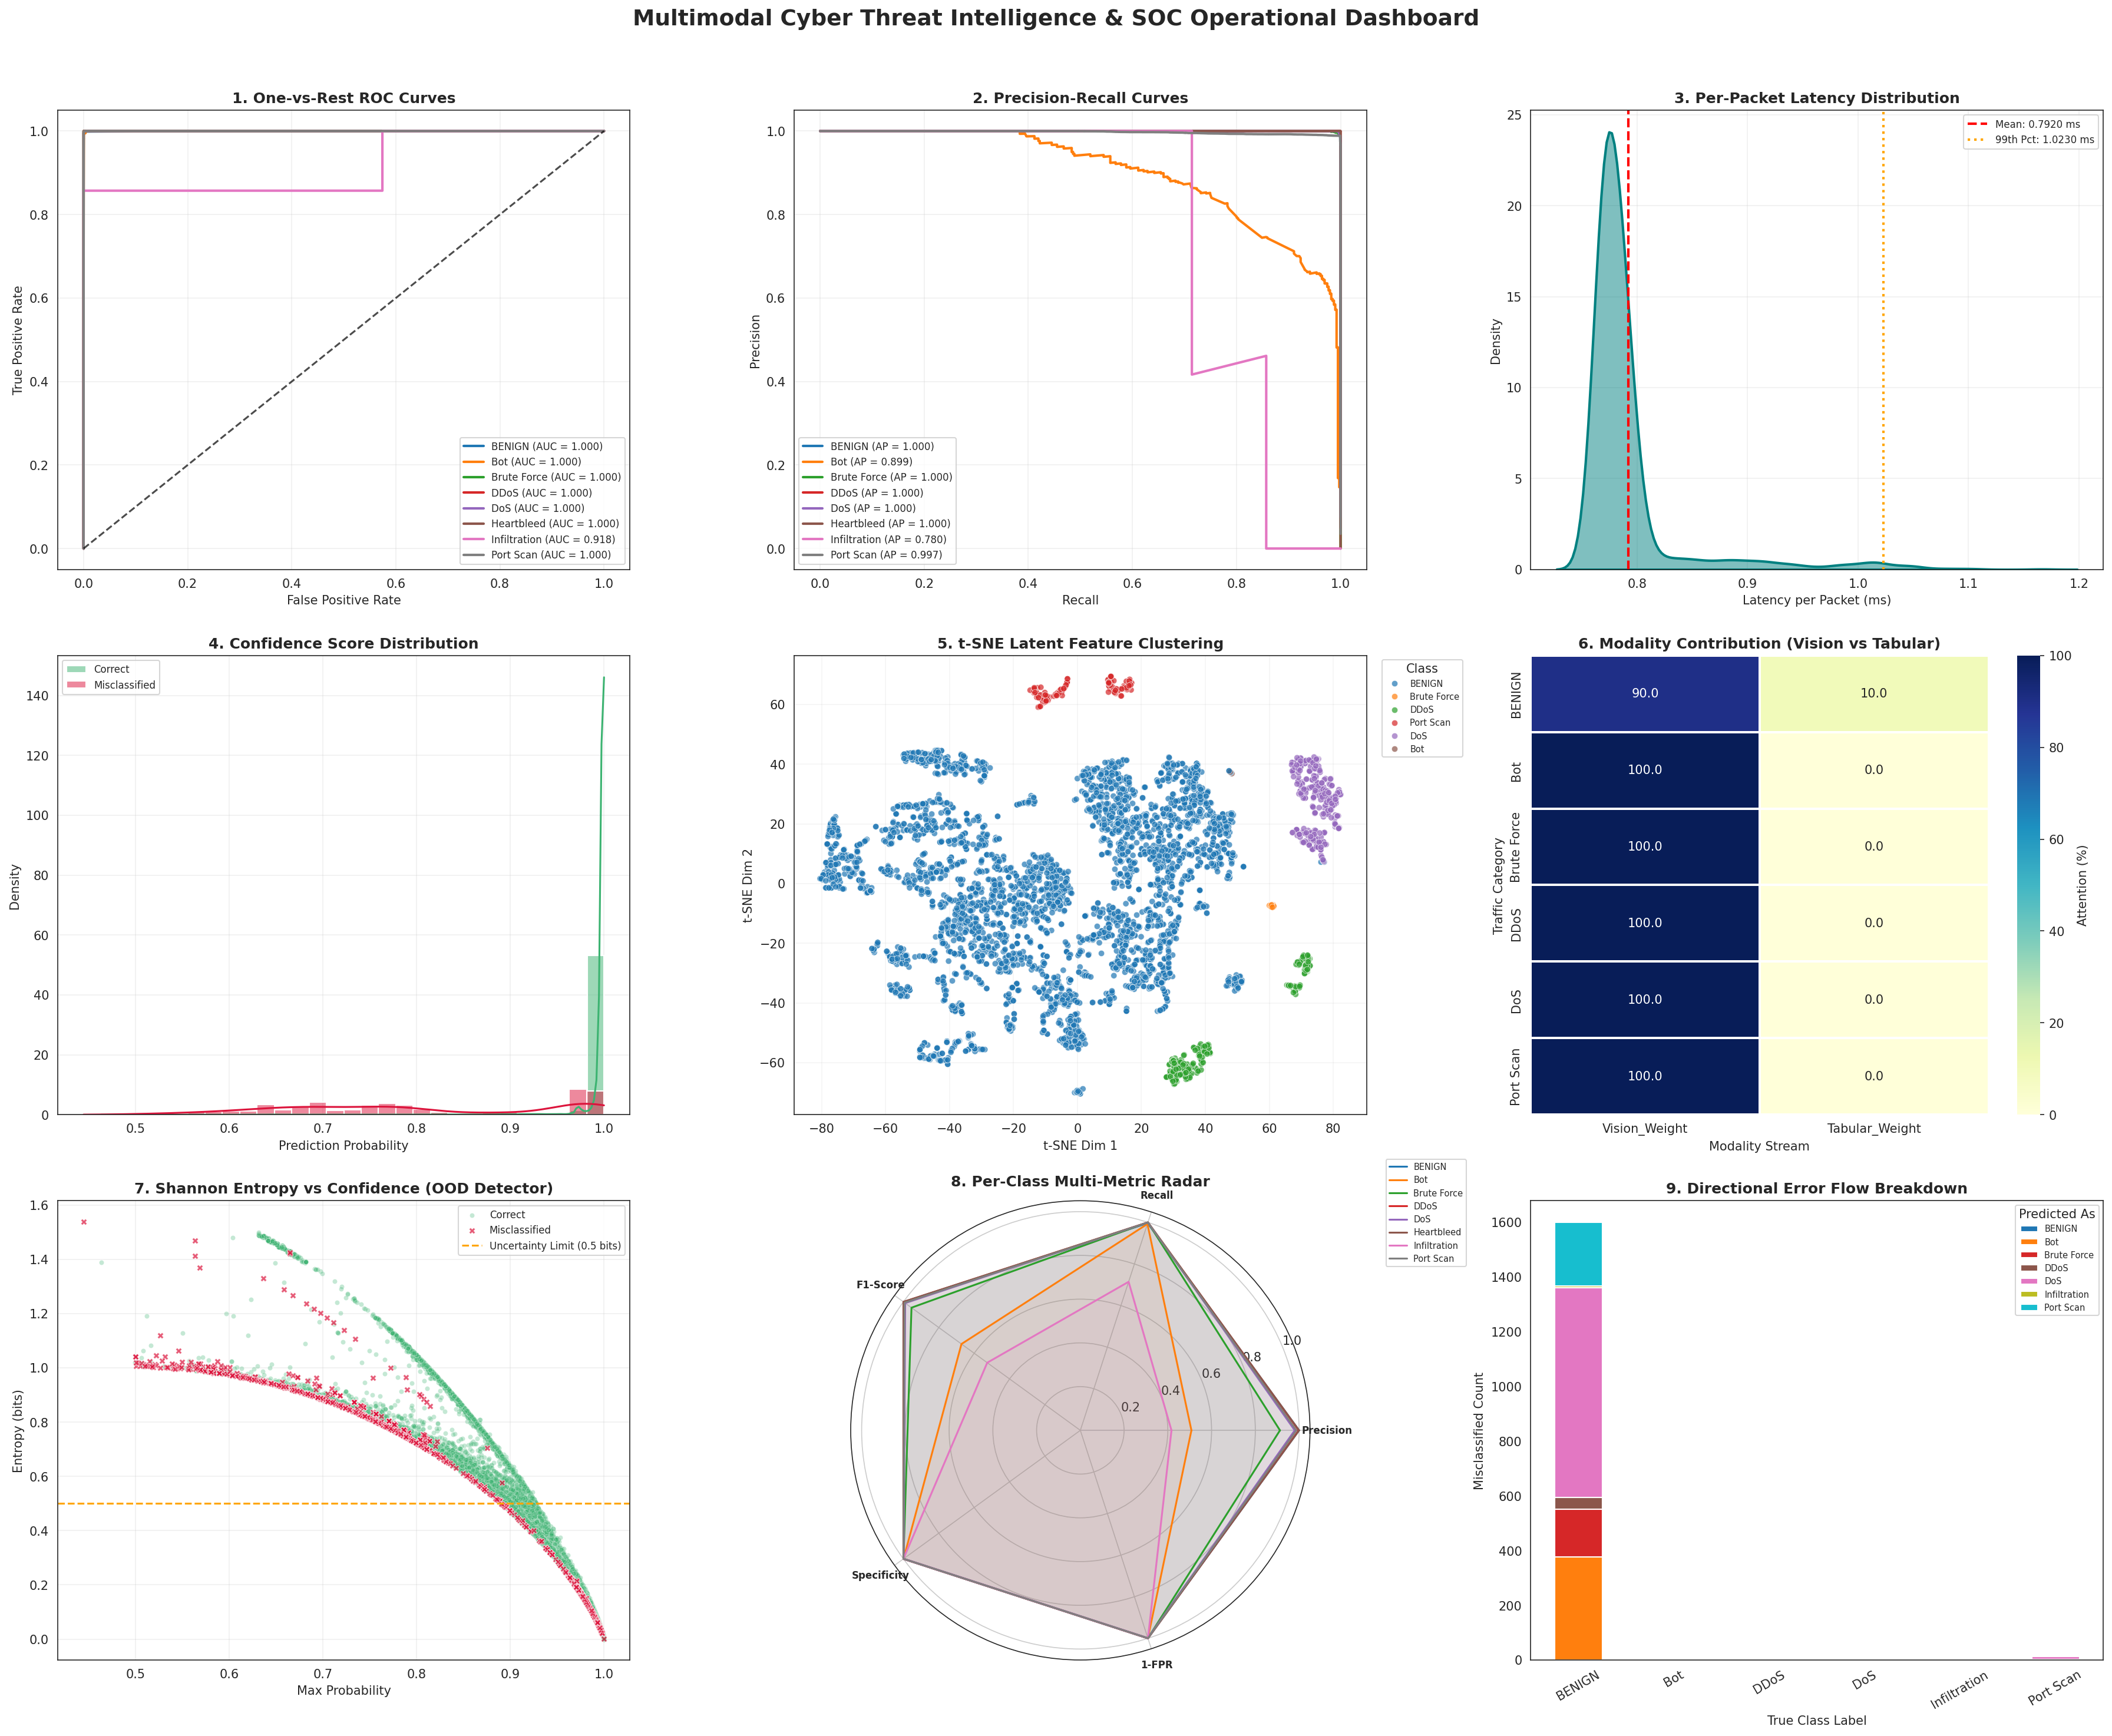

⚡ OPERATIONAL PERFORMANCE SUMMARY:
   • Mean Per-Packet Latency : 0.7920 ms (1,263 packets/sec)
   • 99th Percentile Latency : 1.0230 ms
   • Total Error Rate        : 0.32%
✅ Unified Analytics Suite Execution Complete.


In [ ]:
# ==============================================================================
# CELL 15: COMPREHENSIVE MULTIMODAL SECURITY & OPERATIONAL INTELLIGENCE SUITE
# ==============================================================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
from sklearn.manifold import TSNE
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    precision_recall_fscore_support, confusion_matrix
)

print("🚀 Executing Unified Multimodal Diagnostics & Operational Analytics Suite...")

# ------------------------------------------------------------------------------
# 1. BENCHMARK INFERENCE LATENCY & EXTRACT FEATURE EMBEDDINGS + ATTENTION WEIGHTS
# ------------------------------------------------------------------------------
model.eval()
latencies = []
batch_sizes = []
fused_embeddings = []
attention_weights = []
extracted_labels = []

MAX_TSNE_SAMPLES = 5000
sample_counter = 0

with torch.no_grad():
    for tab, img, labels in test_loader:
        tab, img = tab.to(device), img.to(device)

        # --- Precise GPU/CPU Timing ---
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start_time = time.perf_counter()

        # Forward Pass
        z_v = model.resnet(img)
        z_t = model.mlp(tab)
        combined = torch.cat((z_v, z_t), dim=1)
        attn = model.attention(combined)
        fused = attn[:, 0].unsqueeze(1) * z_v + attn[:, 1].unsqueeze(1) * z_t
        out = model.classifier(fused)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        end_time = time.perf_counter()

        # Log Latency
        elapsed_ms = (end_time - start_time) * 1000
        latencies.append(elapsed_ms)
        batch_sizes.append(len(tab))

        # Log Embeddings & Attention up to sample limit
        if sample_counter < MAX_TSNE_SAMPLES:
            fused_embeddings.append(fused.cpu().numpy())
            attention_weights.append(attn.cpu().numpy())
            extracted_labels.append(labels.numpy())
            sample_counter += len(labels)

# Process Latency Metrics
per_sample_latencies_ms = np.array(latencies) / np.array(batch_sizes)
avg_lat = np.mean(per_sample_latencies_ms)
p99_lat = np.percentile(per_sample_latencies_ms, 99)

# Process Embeddings & Attention Data
fused_embeddings = np.vstack(fused_embeddings)[:MAX_TSNE_SAMPLES]
attention_weights = np.vstack(attention_weights)[:MAX_TSNE_SAMPLES]
extracted_labels = np.concatenate(extracted_labels)[:MAX_TSNE_SAMPLES]
sample_label_names = np.array([le.classes_[i] for i in extracted_labels])

# ------------------------------------------------------------------------------
# 2. STATISTICAL & UNCERTAINTY COMPUTATIONS
# ------------------------------------------------------------------------------
# Setup Binarized Labels
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_bin.shape[1]

# Prediction Confidence & Correctness
max_confidences = np.max(y_score, axis=1)
is_correct = (y_true == y_pred)

# Predictive Entropy H(P) = -sum(p * log2(p)) for OOD/Zero-Day Detection
probs_clamped = np.clip(y_score, 1e-12, 1.0)
predictive_entropy = entropy(probs_clamped, axis=1, base=2)

# Compute t-SNE Reduction
print(f"🔄 Computing t-SNE projection on {len(fused_embeddings):,} samples...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
tsne_results = tsne.fit_transform(fused_embeddings)

# Compute Modality Contribution Summary
attn_df = pd.DataFrame({
    'Class': sample_label_names,
    'Vision_Weight': attention_weights[:, 0],
    'Tabular_Weight': attention_weights[:, 1]
})
modality_summary = attn_df.groupby('Class').mean() * 100

# Compute Multi-Metric Radar Stats
present_labels = np.unique(y_true)
cm = confusion_matrix(y_true, y_pred, labels=present_labels)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)

specificity, fpr_list = [], []
for i in range(len(present_labels)):
    tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
    fp = np.sum(cm[:, i]) - cm[i, i]
    spec = tn / (tn + fp + 1e-6)
    fpr_val = fp / (fp + tn + 1e-6)
    specificity.append(spec)
    fpr_list.append(fpr_val)

# ------------------------------------------------------------------------------
# 3. RENDER INTEGRATED 9-PANEL DASHBOARD (3x3 GRID)
# ------------------------------------------------------------------------------
fig = plt.figure(figsize=(24, 20))
plt.suptitle("Multimodal Cyber Threat Intelligence & SOC Operational Dashboard", fontsize=18, fontweight='bold', y=0.98)

# --- Subplot 1: ROC Curves ---
ax1 = plt.subplot(3, 3, 1)
for i in range(n_classes):
    fpr_c, tpr_c, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr_c, tpr_c)
    ax1.plot(fpr_c, tpr_c, lw=2, label=f'{target_names[i]} (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.7)
ax1.set_title("1. One-vs-Rest ROC Curves", fontweight='bold', fontsize=12)
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(loc="lower right", fontsize=8)
ax1.grid(True, alpha=0.3)

# --- Subplot 2: Precision-Recall Curves ---
ax2 = plt.subplot(3, 3, 2)
for i in range(n_classes):
    prec_c, rec_c, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_score[:, i])
    ax2.plot(rec_c, prec_c, lw=2, label=f'{target_names[i]} (AP = {ap:.3f})')
ax2.set_title("2. Precision-Recall Curves", fontweight='bold', fontsize=12)
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(loc="lower left", fontsize=8)
ax2.grid(True, alpha=0.3)

# --- Subplot 3: Inference Speed Latency Distribution ---
ax3 = plt.subplot(3, 3, 3)
sns.kdeplot(per_sample_latencies_ms, ax=ax3, fill=True, color="teal", alpha=0.5, lw=2)
ax3.axvline(avg_lat, color='red', linestyle='--', lw=2, label=f'Mean: {avg_lat:.4f} ms')
ax3.axvline(p99_lat, color='orange', linestyle=':', lw=2, label=f'99th Pct: {p99_lat:.4f} ms')
ax3.set_title("3. Per-Packet Latency Distribution", fontweight='bold', fontsize=12)
ax3.set_xlabel("Latency per Packet (ms)")
ax3.set_ylabel("Density")
ax3.legend(loc="upper right", fontsize=8)
ax3.grid(True, alpha=0.3)

# --- Subplot 4: Confidence Score Distribution ---
ax4 = plt.subplot(3, 3, 4)
sns.histplot(max_confidences[is_correct], ax=ax4, color="mediumseagreen", label="Correct", bins=30, kde=True, stat="density", alpha=0.5)
sns.histplot(max_confidences[~is_correct], ax=ax4, color="crimson", label="Misclassified", bins=30, kde=True, stat="density", alpha=0.5)
ax4.set_title("4. Confidence Score Distribution", fontweight='bold', fontsize=12)
ax4.set_xlabel("Prediction Probability")
ax4.set_ylabel("Density")
ax4.legend(loc="upper left", fontsize=8)
ax4.grid(True, alpha=0.3)

# --- Subplot 5: t-SNE Feature Space Clusters ---
ax5 = plt.subplot(3, 3, 5)
palette = sns.color_palette("tab10", len(np.unique(sample_label_names)))
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=sample_label_names, palette=palette, alpha=0.7, s=25, ax=ax5)
ax5.set_title("5. t-SNE Latent Feature Clustering", fontweight='bold', fontsize=12)
ax5.set_xlabel("t-SNE Dim 1")
ax5.set_ylabel("t-SNE Dim 2")
ax5.legend(title="Class", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax5.grid(True, alpha=0.2)

# --- Subplot 6: Modality Contribution Heatmap ---
ax6 = plt.subplot(3, 3, 6)
sns.heatmap(modality_summary, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Attention (%)'}, vmin=0, vmax=100, linewidths=1, ax=ax6)
ax6.set_title("6. Modality Contribution (Vision vs Tabular)", fontweight='bold', fontsize=12)
ax6.set_xlabel("Modality Stream")
ax6.set_ylabel("Traffic Category")

# --- Subplot 7: Predictive Entropy vs Confidence ---
ax7 = plt.subplot(3, 3, 7)
sns.scatterplot(x=max_confidences[is_correct], y=predictive_entropy[is_correct], color='mediumseagreen', alpha=0.3, label='Correct', ax=ax7, s=15)
sns.scatterplot(x=max_confidences[~is_correct], y=predictive_entropy[~is_correct], color='crimson', alpha=0.7, label='Misclassified', ax=ax7, s=25, marker='X')
ax7.axhline(0.5, color='orange', linestyle='--', label='Uncertainty Limit (0.5 bits)')
ax7.set_title("7. Shannon Entropy vs Confidence (OOD Detector)", fontweight='bold', fontsize=12)
ax7.set_xlabel("Max Probability")
ax7.set_ylabel("Entropy (bits)")
ax7.legend(loc='upper right', fontsize=8)
ax7.grid(True, alpha=0.3)

# --- Subplot 8: Multi-Metric Radar Chart ---
ax8 = plt.subplot(3, 3, 8, polar=True)
metrics_labels = ['Precision', 'Recall', 'F1-Score', 'Specificity', '1-FPR']
num_vars = len(metrics_labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

for i, c_name in enumerate(target_names[:len(present_labels)]):
    values = [precision[i], recall[i], f1[i], specificity[i], 1 - fpr_list[i]]
    values += values[:1]
    ax8.plot(angles, values, linewidth=1.5, label=c_name)
    ax8.fill(angles, values, alpha=0.05)

ax8.set_xticks(angles[:-1])
ax8.set_xticklabels(metrics_labels, fontsize=8, fontweight='bold')
ax8.set_ylim(0, 1.05)
ax8.set_title("8. Per-Class Multi-Metric Radar", fontweight='bold', fontsize=12, pad=12)
ax8.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=7)

# --- Subplot 9: Directional Misclassification Flow ---
ax9 = plt.subplot(3, 3, 9)
error_mask = (y_true != y_pred)
err_true = y_true[error_mask]
err_pred = y_pred[error_mask]

if len(err_true) > 0:
    err_df = pd.DataFrame({
        'True Class': [le.classes_[i] for i in err_true],
        'Predicted Class': [le.classes_[i] for i in err_pred]
    })
    error_counts = err_df.groupby(['True Class', 'Predicted Class']).size().unstack(fill_value=0)
    error_counts.plot(kind='bar', stacked=True, ax=ax9, colormap='tab10')
    ax9.set_title("9. Directional Error Flow Breakdown", fontweight='bold', fontsize=12)
    ax9.set_xlabel("True Class Label")
    ax9.set_ylabel("Misclassified Count")
    ax9.legend(title="Predicted As", fontsize=7, loc='upper right')
    ax9.tick_params(axis='x', rotation=30)
else:
    ax9.text(0.5, 0.5, "100% Accuracy!\nNo Errors Detected.", ha='center', va='center', fontsize=12, fontweight='bold')
    ax9.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ------------------------------------------------------------------------------
# 4. BENCHMARK SUMMARY OUTPUT
# ------------------------------------------------------------------------------
print("=" * 70)
print("⚡ OPERATIONAL PERFORMANCE SUMMARY:")
print(f"   • Mean Per-Packet Latency : {avg_lat:.4f} ms ({1000/avg_lat:,.0f} packets/sec)")
print(f"   • 99th Percentile Latency : {p99_lat:.4f} ms")
print(f"   • Total Error Rate        : {np.mean(~is_correct)*100:.2f}%")
print("=" * 70)
print("✅ Unified Analytics Suite Execution Complete.")

🔍 Running Final Evaluation: 100%|██████████| 2012/2012 [12:27<00:00,  2.69it/s]



🏆 GLOBAL PERFORMANCE SUMMARY (100% DATASET SCALE)
OVERALL ACCURACY:  99.6822%
MACRO PRECISION:   0.8839
MACRO RECALL:      0.9627
MACRO F1-SCORE:    0.9115


,precision,recall,f1-score
BENIGN,1.0000,0.9963,0.9981
Bot,0.4714,0.9923,0.6392
Brute Force,0.9182,1.0000,0.9574
DDoS,0.9988,0.9998,0.9993
DoS,0.9808,0.9998,0.9902
Heartbleed,1.0000,1.0000,1.0000
Infiltration,0.7143,0.7143,0.7143
Port Scan,0.9875,0.9993,0.9934


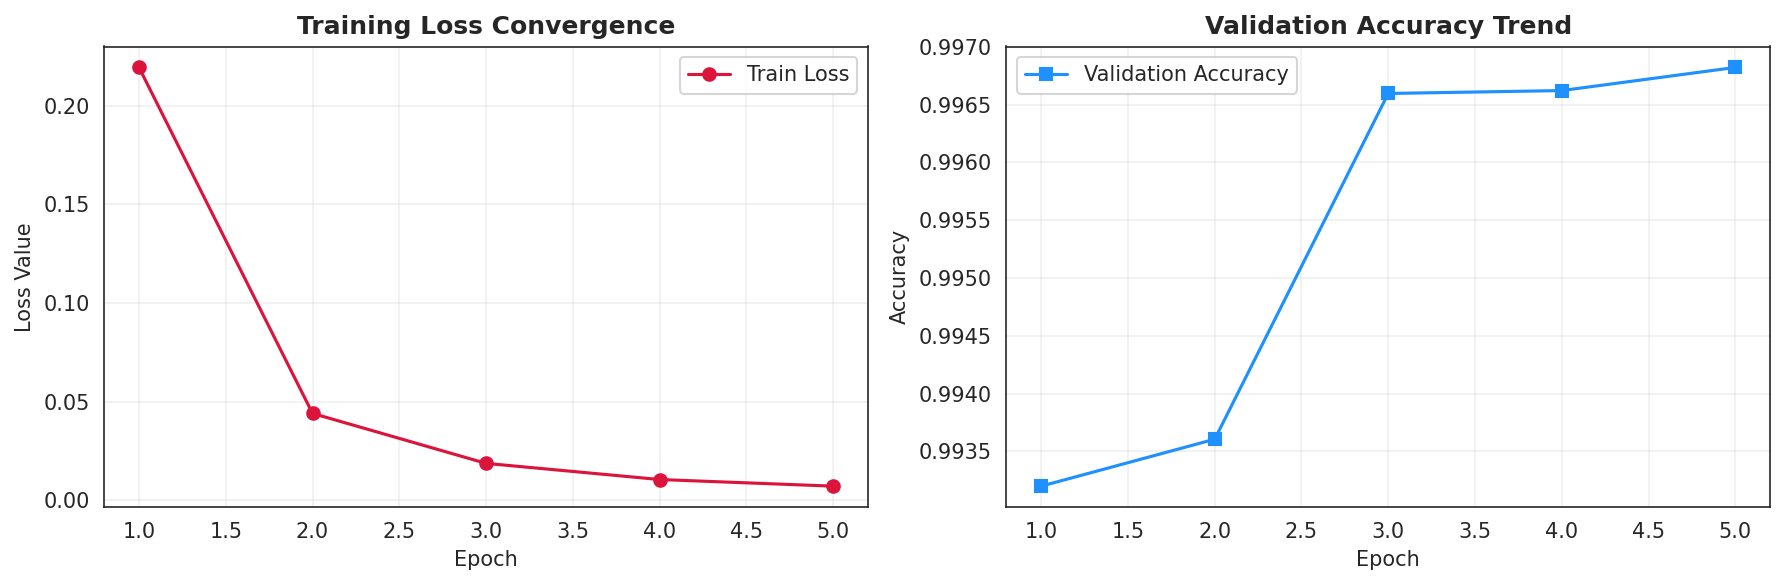

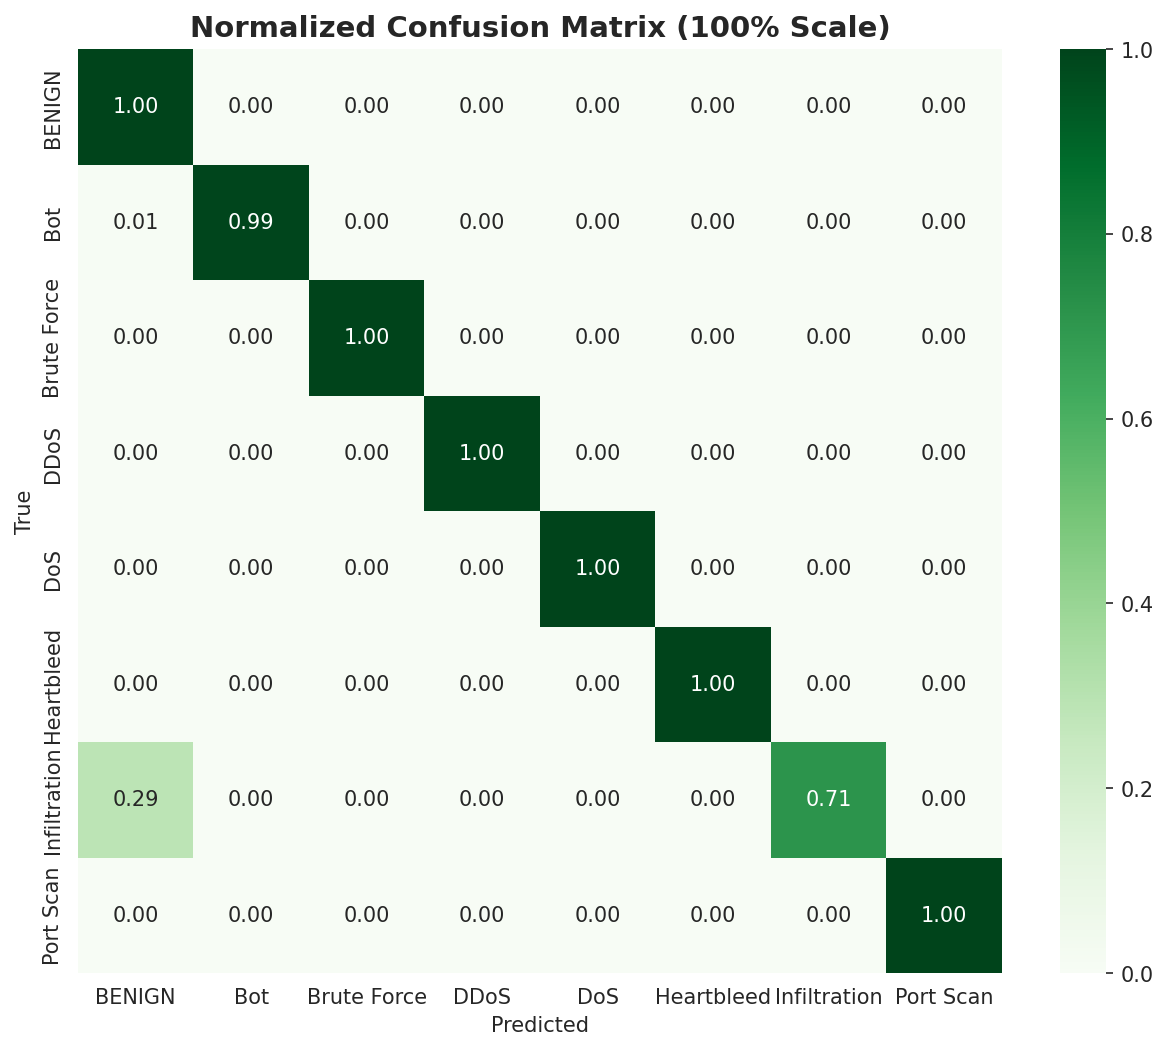

In [ ]:
# ==============================================================================
# CELL 13: EVALUATION & METRICS SUITE
# ==============================================================================
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, precision_recall_fscore_support,
    confusion_matrix, roc_curve, auc, accuracy_score,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize

model.eval()
y_true, y_pred, y_score = [], [], []

with torch.no_grad():
    for tab, img, labels in tqdm(test_loader, desc="🔍 Running Final Evaluation"):
        tab, img = tab.to(device), img.to(device)
        outputs = model(tab, img)
        probs = torch.softmax(outputs, dim=1)
        y_true.extend(labels.numpy())
        y_pred.extend(torch.argmax(probs, dim=1).cpu().numpy())
        y_score.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

present_labels = np.unique(y_true)
target_names = [le.classes_[i] for i in present_labels]

acc = accuracy_score(y_true, y_pred)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

print("\n" + "="*60)
print(f"🏆 GLOBAL PERFORMANCE SUMMARY (100% DATASET SCALE)")
print("="*60)
print(f"OVERALL ACCURACY:  {acc:.4%}")
print(f"MACRO PRECISION:   {p_macro:.4f}")
print(f"MACRO RECALL:      {r_macro:.4f}")
print(f"MACRO F1-SCORE:    {f1_macro:.4f}")
print("="*60)

report_dict = classification_report(
    y_true, y_pred, labels=present_labels, target_names=target_names, digits=4, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.iloc[:-3, :3].style.background_gradient(cmap='Blues').format("{:.4f}"))

# Loss & Accuracy Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, total_epochs + 1), history['train_loss'], marker='o', color='crimson', label='Train Loss')
plt.title("Training Loss Convergence", fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, total_epochs + 1), history['val_acc'], marker='s', color='dodgerblue', label='Validation Accuracy')
plt.title("Validation Accuracy Trend", fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Normalized Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=present_labels)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=target_names, yticklabels=target_names, square=True)
plt.title("Normalized Confusion Matrix (100% Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()